In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
folder_path = '/content/drive/MyDrive/MAJOR_PROJECT/'
os.makedirs(folder_path, exist_ok=True)

In [ ]:
notebook_source = '/content/drive/MyDrive/MAJOR_PROJECT/L_Project/4_Regression_Models.ipynb'
notebook_dest = os.path.join(folder_path, '4_Regression_Models.ipynb')

!cp "{notebook_source}" "{notebook_dest}"
print(f"Notebook saved to: {notebook_dest}")

Notebook saved to: /content/drive/MyDrive/MAJOR_PROJECT/4_Regression_Models.ipynb


## Import libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt


## Load the data set

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/descriptors_output.csv')

## Input features

In [ ]:
X = df.drop('pIC50', axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
203,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
204,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
205,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### Output features

In [ ]:
Y = df.pIC50
Y

,pIC50
0,7.853872
1,6.146910
2,6.342944
3,6.094744
4,5.000000
...,...
202,5.000000
203,5.000000
204,5.000000
205,5.000000


### Remove low variance features

In [ ]:
def remove_low_variance(input_data, threshold=0.10):
    numeric_data = input_data.select_dtypes(include=['float64', 'int64'])
    selector = VarianceThreshold(threshold)
    X_reduced = selector.fit_transform(numeric_data)
    selected_cols = numeric_data.columns[selector.get_support()]
    return pd.DataFrame(X_reduced, columns=selected_cols, index=input_data.index)

In [ ]:
X = remove_low_variance(X, threshold = 0.10)

In [ ]:
X.shape

(207, 179)

### Data split (80/20 ratio)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, Y_train.shape

((165, 179), (165,))

In [ ]:
X_test.shape, Y_test.shape

((42, 179), (42,))

In [ ]:
results = []

# Regression Model

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X)
Y_scaled = scaler.fit_transform(Y.values.reshape(-1, 1)).ravel()

### Random Forest

### Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

best_rf = RandomForestRegressor(
    max_depth=30,
    max_features=0.5,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Perform cross-validation on training data
scores = cross_val_score(best_rf, X_train_scaled, Y_train, cv=5, scoring='r2', n_jobs=-1)

print("Cross-validated R² scores:", scores)
print("Mean R²:", np.mean(scores))


Cross-validated R² scores: [0.72774223 0.81825873 0.78703894 0.7822664  0.82922112]
Mean R²: 0.7889054831662385


In [ ]:
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = np.mean(np.abs(Y_test - Y_pred))

In [ ]:
print("Random Forest")
print(f"R2: {r2:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAE: {mae:.3f}")

Random Forest
R2: 0.886, MSE: 0.445, RMSE: 0.667, MAE: 0.435


In [ ]:
results.append(["Random Forest", r2, mse, rmse, mae])

### SVR Tuning

In [ ]:
svr_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.2, 0.5]
}
svr = SVR(kernel='rbf')
svr_grid = GridSearchCV(svr, svr_param_grid, cv=5, scoring='r2', n_jobs=-1)
svr_grid.fit(X_train_scaled, Y_train)
best_svr = svr_grid.best_estimator_
print("Best SVR Params:", svr_grid.best_params_)

Best SVR Params: {'C': 10, 'epsilon': 0.01, 'gamma': 0.01}


## scaled y

In [ ]:
Y_pred_svr = best_svr.predict(X_test_scaled)
r2_svr = r2_score(Y_test, Y_pred_svr)
mse_svr = mean_squared_error(Y_test, Y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(Y_test, Y_pred_svr)

In [ ]:
print("SVR")
print(f"R2: {r2_svr:.3f}, MSE: {mse_svr:.3f}, RMSE: {rmse_svr:.3f}, MAE: {mae_svr:.3f}")

SVR
R2: 0.872, MSE: 0.499, RMSE: 0.706, MAE: 0.483


In [ ]:
results.append(["SVR", r2_svr, mse_svr, rmse_svr, mae_svr])

### Gradient Boost Tuning

In [ ]:
gbm_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5]
}
gbm = GradientBoostingRegressor(random_state=42)
gbm_grid = GridSearchCV(gbm, gbm_param_grid, cv=5, scoring='r2', n_jobs=-1)
gbm_grid.fit(X_train, Y_train)
best_gbm = gbm_grid.best_estimator_
print("Best GBM Params:", gbm_grid.best_params_)

Best GBM Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}


In [ ]:
Y_pred_gbm = best_gbm.predict(X_test)
r2_gbm = r2_score(Y_test, Y_pred_gbm)
mse_gbm = mean_squared_error(Y_test, Y_pred_gbm)
rmse_gbm = np.sqrt(mse_gbm)
mae_gbm = mean_absolute_error(Y_test, Y_pred_gbm)

In [ ]:
print("Gradient Boost")
print(f"R2: {r2_gbm:.3f}, MSE: {mse_gbm:.3f}, RMSE: {rmse_gbm:.3f}, MAE: {mae_gbm:.3f}")

Gradient Boost
R2: 0.855, MSE: 0.563, RMSE: 0.751, MAE: 0.504


In [ ]:
results.append(["Gradient Boost", r2_gbm, mse_gbm, rmse_gbm, mae_gbm])

In [ ]:
results_df = pd.DataFrame(results, columns=['Model', 'R2', 'MSE', 'RMSE', 'MAE'])
print("\n📊 Model Performance Comparison:\n")
print(results_df)


📊 Model Performance Comparison:

            Model        R2       MSE      RMSE       MAE
0   Random Forest  0.885605  0.444670  0.666836  0.435038
1             SVR  0.871692  0.498754  0.706225  0.483226
2  Gradient Boost  0.855093  0.563274  0.750516  0.503635


### Use of Best Model

In [ ]:
best_result = results_df.loc[results_df['R2'].idxmax()]
best_model_name = best_result['Model']
print(f"\nBest model based on R²: {best_model_name} (R2 = {best_result['R2']:.4f})")


Best model based on R²: Random Forest (R2 = 0.8856)


In [ ]:
Best_Model_Result = pd.DataFrame({
    "True_pIC50": Y_test,
    "Pred_pIC50": Y_pred
})

In [ ]:

file_path = os.path.join(folder_path, 'L_DATASET_1/regression_model.csv')
Best_Model_Result.to_csv(file_path, index=False)
print(f"CSV saved to: {file_path}")

CSV saved to: /content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/regression_model.csv


## Scatter Plot

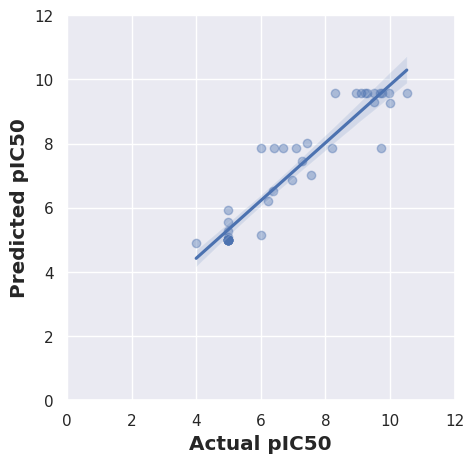

In [ ]:
sns.set(color_codes=True)
ax = sns.regplot(x=Y_test, y=Y_pred, scatter_kws={'alpha':0.4})
ax.set_xlabel('Actual pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()

In [ ]:
errors = Y_pred - Y_test
threshold = 1
high_error_idx = np.where(np.abs(errors) > threshold)[0]
print(f"Number of high-error compounds (> {threshold} pIC50 units): {len(high_error_idx)}")

Number of high-error compounds (> 1 pIC50 units): 5


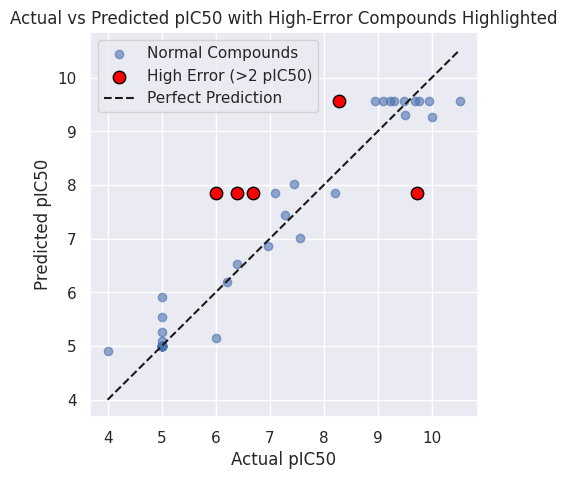

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(Y_test, Y_pred, alpha=0.6, label="Normal Compounds")
plt.scatter(Y_test.iloc[high_error_idx], Y_pred[high_error_idx],
            color="red", edgecolor="black", s=80, label="High Error (>1 pIC50)")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', label="Perfect Prediction")
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50 with High-Error Compounds Highlighted")
plt.legend()
plt.show()

### Low- Variance Analysis

In [ ]:
def remove_low_variance(input_data, threshold=0.01):
    numeric_data = input_data.select_dtypes(include=['float64', 'int64'])
    selector = VarianceThreshold(threshold)
    X_reduced = selector.fit_transform(numeric_data)
    selected_cols = numeric_data.columns[selector.get_support()]
    return pd.DataFrame(X_reduced, columns=selected_cols, index=input_data.index)

thresholds_to_test = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5, 1.0]
results = []

for threshold in thresholds_to_test:
    X_filtered = None
    try:
        X_filtered = remove_low_variance(X, threshold=threshold)

        if X_filtered.shape[1] == 0:
            results.append({
                'Threshold': threshold,
                'Number of Features': 0,
                'R2 Score': np.nan,
                'MSE': np.nan
            })
            print(f"Threshold {threshold}: Removed all features.")
            continue

        X_train, X_test, Y_train, Y_test = train_test_split(X_filtered, Y, test_size=0.2, random_state=42)

        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, Y_train)

        Y_pred = model.predict(X_test)

        r2 = r2_score(Y_test, Y_pred)
        mse = mean_squared_error(Y_test, Y_pred)

        results.append({
            'Threshold': threshold,
            'Number of Features': X_filtered.shape[1],
            'R2 Score': r2,
            'MSE': mse
        })
        print(f"Threshold {threshold}: {X_filtered.shape[1]} features selected. R2 Score: {r2:.4f}, MSE: {mse:.4f}")

    except ValueError as e:
        results.append({
            'Threshold': threshold,
            'Number of Features': 0,
            'R2 Score': np.nan,
            'MSE': np.nan
        })
        print(f"Threshold {threshold}: Encountered an error during filtering: {e}")
        print("This often means all features had variance below the threshold.")

results_df = pd.DataFrame(results)
print("\nFinal Results Table:")
print(results_df)

Threshold 0.0: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.001: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.005: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.01: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.02: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.05: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.1: 179 features selected. R2 Score: 0.8861, MSE: 0.4429
Threshold 0.5: Encountered an error during filtering: No feature in X meets the variance threshold 0.50000
This often means all features had variance below the threshold.
Threshold 1.0: Encountered an error during filtering: No feature in X meets the variance threshold 1.00000
This often means all features had variance below the threshold.

Final Results Table:
   Threshold  Number of Features  R2 Score       MSE
0      0.000                 179  0.886061  0.442896
1      0.001                 179  0.886061  0.4

# High Error Compunds

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/MAJOR_PROJECT/L_DATASET_1/Final_bioactivity_noIntermediate_pIC50.csv')

### Identify High-Error Compounds

In [ ]:
errors = Y_pred - Y_test
threshold = 1

high_error_idx = np.where(np.abs(errors) > threshold)[0]

print(f"Number of high-error compounds (> {threshold} pIC50 units): {len(high_error_idx)}")

high_error_df = df2.loc[Y_test.index].reset_index(drop=True).iloc[high_error_idx].copy()
high_error_df["Actual_pIC50"] = Y_test.iloc[high_error_idx].values
high_error_df["Pred_pIC50"] = Y_pred[high_error_idx]
high_error_df["Error"] = high_error_df["Pred_pIC50"] - high_error_df["Actual_pIC50"]

# Display top high-error compounds
high_error_df[['molecule_chembl_id', 'canonical_smiles', 'Actual_pIC50', 'Pred_pIC50', 'Error']]
high_error_df.head()

Number of high-error compounds (> 1 pIC50 units): 5


,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50,Actual_pIC50,Pred_pIC50,Error
11,CHEMBL504759,CC(C)C[C@H](NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@...,active,3395.743,-16.25783,51.0,48.0,6.000000,6.000000,7.835364,1.835364
14,CHEMBL428139,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3355.718,-14.49400,49.0,47.0,9.721246,9.721246,7.835364,-1.885883
15,CHEMBL5201793,CC[C@H](NC(=O)[C@H](CC)NC(=O)[C@@H](NC(=O)[C@H...,active,3289.794,-8.47153,45.0,42.0,6.399997,6.399997,7.835364,1.435367
17,CHEMBL5194409,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,3251.657,-12.33313,47.0,44.0,6.699992,6.699992,7.835364,1.135372
28,CHEMBL3616745,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,active,4029.479,-13.96846,57.0,56.0,8.287350,8.287350,9.570299,1.282948


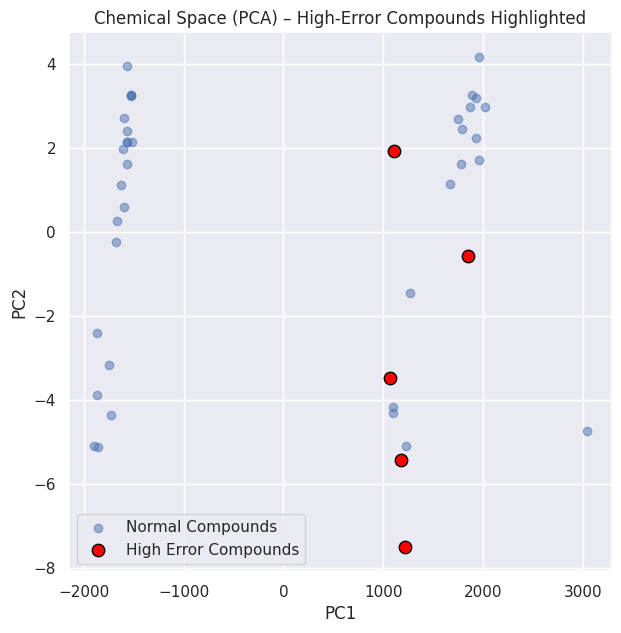

In [ ]:
df2_test = df2.loc[Y_test.index].reset_index(drop=True)
desc_cols = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
X = df2_test[desc_cols].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,7))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, label="Normal Compounds")
plt.scatter(
    X_pca[high_error_idx, 0],
    X_pca[high_error_idx, 1],
    color="red", edgecolor="black", s=80, label="High Error Compounds"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Chemical Space (PCA) – High-Error Compounds Highlighted")
plt.legend()
plt.show()

In [ ]:
df2_test = df2.loc[Y_test.index].reset_index(drop=True).copy()
df2_test["Actual_pIC50"] = Y_test.values
df2_test["Pred_pIC50"] = Y_pred
df2_test["Error"] = df2_test["Pred_pIC50"] - df2_test["Actual_pIC50"]
df2_test["High_Error"] = np.abs(df2_test["Error"]) > 1


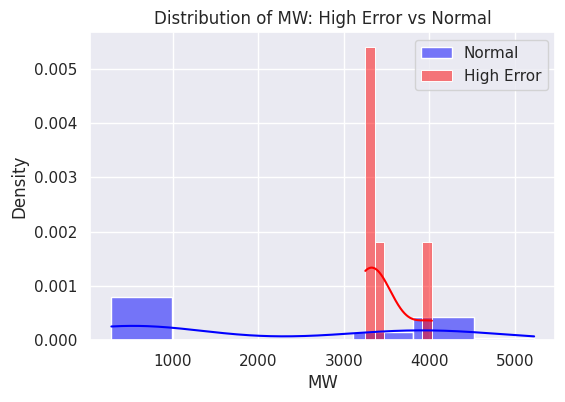

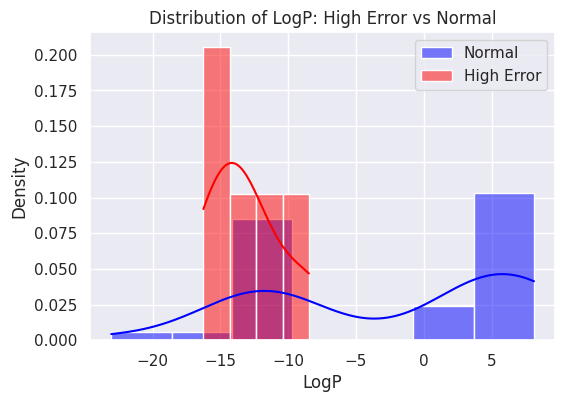

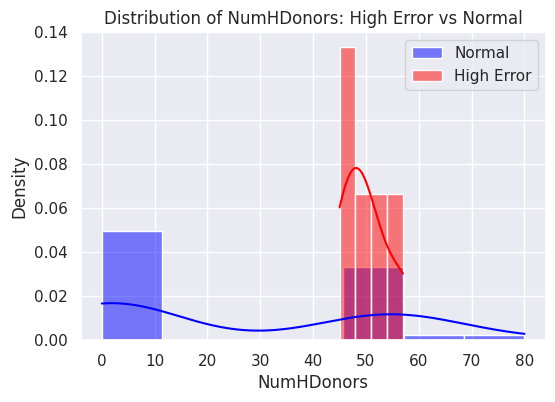

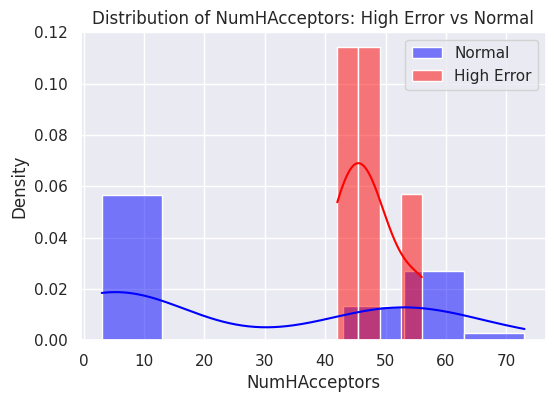

In [ ]:
for col in desc_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df2_test.loc[~df2_test["High_Error"], col],
                 color="blue", alpha=0.5, kde=True, stat="density", label="Normal")
    sns.histplot(df2_test.loc[df2_test["High_Error"], col],
                 color="red", alpha=0.5, kde=True, stat="density", label="High Error")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.title(f"Distribution of {col}: High Error vs Normal")
    plt.legend()
    plt.show()
